# Differentially Private Deep Neural Network - Lung Cancer Dataset

Trains a DP-DNN using Opacus (DP-SGD) on the Lung Cancer dataset (50,000 samples, 23 features, 3-class target).

ε ∈ {0.1, 0.2, 0.4, 0.8, 1.0, 2.0, 4.0, 8.0, 10.0}, 30 runs each.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import os
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from opacus import PrivacyEngine
from opacus.validators import ModuleValidator

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device('cpu')
    print(f"Using CPU")

print(f"PyTorch version: {torch.__version__}")
print(f"Opacus version: {__import__('opacus').__version__}")
print(f"Device: {device}")

W0628 18:11:50.118000 84096 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Using CPU
PyTorch version: 2.11.0
Opacus version: 1.6.0
Device: cpu


## 2. Load Preprocessed Data

In [2]:
with open('../data/processed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
feature_names = data['feature_names']
n_classes = data.get('n_classes', 3)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Number of features: {X_train.shape[1]}")
print(f"Number of classes: {n_classes}")

X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

batch_size = 256
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nData loaded and prepared")

Training set: (40000, 23)
Test set: (10000, 23)
Number of features: 23
Number of classes: 3

Data loaded and prepared


## 3. Load Baseline Results

In [3]:
try:
    baseline_df = pd.read_csv('output/baseline_dnn_results.csv')
    baseline_accuracy = baseline_df['accuracy'].values[0]
    baseline_f1 = baseline_df['f1_score'].values[0]
    print(f"Baseline results loaded")
    print(f"  Baseline Accuracy: {baseline_accuracy:.4f}")
    print(f"  Baseline F1-Score: {baseline_f1:.4f}")
except FileNotFoundError:
    print("output/baseline_dnn_results.csv not found - run STD_DNN.ipynb first")
    baseline_accuracy = None
    baseline_f1 = None

Baseline results loaded
  Baseline Accuracy: 1.0000
  Baseline F1-Score: 1.0000


## 4. Define DP-DNN Architecture

In [4]:
class DPDNNClassifier(nn.Module):
    def __init__(self, input_size, hidden_sizes=[128, 64], num_classes=3, dropout=0.3):
        super(DPDNNClassifier, self).__init__()
        layers = []
        prev_size = input_size
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_size = hidden_size
        layers.append(nn.Linear(prev_size, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

input_size = X_train.shape[1]
hidden_sizes = [128, 64]
num_classes = n_classes
dropout = 0.3
learning_rate = 0.001
num_epochs = 30  # Reduced for DP training efficiency

print(f"DP-DNN Architecture:")
print(f"  Input: {input_size}")
print(f"  Hidden: {hidden_sizes}")
print(f"  Output: {num_classes} classes")
print(f"  Dropout: {dropout}")
print(f"  Epochs: {num_epochs}")

DP-DNN Architecture:
  Input: 23
  Hidden: [128, 64]
  Output: 3 classes
  Dropout: 0.3
  Epochs: 30


## 5. Training Functions

In [5]:
def train_dp_model(model, train_loader, criterion, optimizer, privacy_engine,
                   num_epochs, device, delta, verbose=False):
    model.train()
    train_losses = []
    epsilons = []
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)
        epsilon = privacy_engine.get_epsilon(delta=delta)
        epsilons.append(epsilon)
        if verbose and (epoch + 1) % 10 == 0:
            print(f"  Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, ε: {epsilon:.2f}")
    return train_losses, epsilons


def evaluate_model(model, test_loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)


print("Training functions defined")

Training functions defined


## 6. Full Sweep Across Epsilon Values

In [6]:
N_RUNS = 30
max_grad_norm = 1.0
delta = 1e-5

epsilon_values = [0.1, 0.2, 0.4, 0.8, 1.0, 2.0, 4.0, 8.0, 10.0]

print(f"Privacy Configuration:")
print(f"  N_RUNS per epsilon: {N_RUNS}")
print(f"  δ: {delta:.2e}")
print(f"  Max gradient norm: {max_grad_norm}")
print(f"  Training samples: {len(train_dataset):,}")
print(f"  Epochs: {num_epochs}")
print(f"  Epsilon values: {epsilon_values}")

Privacy Configuration:
  N_RUNS per epsilon: 30
  δ: 1.00e-05
  Max gradient norm: 1.0
  Training samples: 40,000
  Epochs: 30
  Epsilon values: [0.1, 0.2, 0.4, 0.8, 1.0, 2.0, 4.0, 8.0, 10.0]


In [7]:
results = {
    'epsilon': [],
    'accuracy_mean': [],
    'accuracy_std': [],
    'f1_score_mean': [],
    'f1_score_std': [],
    'precision_mean': [],
    'recall_mean': [],
}

all_results = {
    'model_type': 'Differentially Private DNN (DP-SGD via Opacus)',
    'dataset': 'Lung Cancer',
    'n_samples': X_train.shape[0] + X_test.shape[0],
    'n_features': X_train.shape[1],
    'n_classes': n_classes,
    'n_runs_per_epsilon': N_RUNS,
    'epsilon_results': {}
}

print(f"Training DP-DNN across {len(epsilon_values)} epsilon values ({N_RUNS} runs each)...")
print("="*80)

for target_eps in epsilon_values:
    run_accs, run_f1s, run_precisions, run_recalls = [], [], [], []

    for run in range(N_RUNS):
        seed = run * 10 + 42
        torch.manual_seed(seed)
        np.random.seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed)

        train_loader_temp = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

        model = DPDNNClassifier(input_size, hidden_sizes, num_classes, dropout).to(device)
        model = ModuleValidator.fix(model)

        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)

        privacy_engine = PrivacyEngine()
        model, optimizer, train_loader_temp = privacy_engine.make_private_with_epsilon(
            module=model,
            optimizer=optimizer,
            data_loader=train_loader_temp,
            target_epsilon=target_eps,
            target_delta=delta,
            epochs=num_epochs,
            max_grad_norm=max_grad_norm,
        )

        if isinstance(optimizer.noise_multiplier, list):
            optimizer.noise_multiplier = optimizer.noise_multiplier[0]

        train_losses, epsilons = train_dp_model(
            model, train_loader_temp, criterion, optimizer, privacy_engine,
            num_epochs, device, delta
        )

        y_true, y_pred = evaluate_model(model, test_loader, device)

        run_accs.append(accuracy_score(y_true, y_pred))
        run_f1s.append(f1_score(y_true, y_pred, average='weighted', zero_division=0))
        run_precisions.append(precision_score(y_true, y_pred, average='weighted', zero_division=0))
        run_recalls.append(recall_score(y_true, y_pred, average='weighted', zero_division=0))
        if run == 0:
            import sys
            import os
            sys.path.append(os.path.abspath(os.path.join('..', '..')))
            from model_exporter import export_model
            export_model(model, f'output/model/dp_dnn_model_eps_{target_eps}.pt')

    acc_mean, acc_std = np.mean(run_accs), np.std(run_accs)
    f1_mean, f1_std = np.mean(run_f1s), np.std(run_f1s)

    results['epsilon'].append(target_eps)
    results['accuracy_mean'].append(acc_mean)
    results['accuracy_std'].append(acc_std)
    results['f1_score_mean'].append(f1_mean)
    results['f1_score_std'].append(f1_std)
    results['precision_mean'].append(np.mean(run_precisions))
    results['recall_mean'].append(np.mean(run_recalls))

    all_results['epsilon_results'][str(target_eps)] = {
        'epsilon': float(target_eps), 'n_runs': N_RUNS,
        'accuracy_mean': acc_mean, 'accuracy_std': acc_std,
        'f1_mean': f1_mean, 'f1_std': f1_std,
        'precision_mean': np.mean(run_precisions),
        'recall_mean': np.mean(run_recalls),
        'per_run_accuracies': run_accs, 'per_run_f1s': run_f1s,
    }

    print(f"  ε={target_eps:5.1f} | Acc: {acc_mean:.4f}±{acc_std:.4f} | F1: {f1_mean:.4f}±{f1_std:.4f}")

print("="*80)
print("Training complete")

Training DP-DNN across 9 epsilon values (30 runs each)...


PyTorch model successfully exported to output/model/dp_dnn_model_eps_0.1.pt


  ε=  0.1 | Acc: 0.9694±0.0071 | F1: 0.9692±0.0072


PyTorch model successfully exported to output/model/dp_dnn_model_eps_0.2.pt


  ε=  0.2 | Acc: 0.9878±0.0061 | F1: 0.9878±0.0061


...

  ε=  4.0 | Acc: 1.0000±0.0000 | F1: 1.0000±0.0000


PyTorch model successfully exported to output/model/dp_dnn_model_eps_8.0.pt


  ε=  8.0 | Acc: 1.0000±0.0000 | F1: 1.0000±0.0000


PyTorch model successfully exported to output/model/dp_dnn_model_eps_10.0.pt


  ε= 10.0 | Acc: 1.0000±0.0000 | F1: 1.0000±0.0000
Training complete


## 7. Results Summary

In [8]:
results_df = pd.DataFrame(results)

if baseline_accuracy is not None:
    results_df['ACL'] = 1 - (results_df['accuracy_mean'] / baseline_accuracy)
    results_df['accuracy_loss_pct'] = results_df['ACL'] * 100

print("\n" + "="*80)
print("DP-DNN RESULTS SUMMARY (LUNG CANCER DATASET)")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)


DP-DNN RESULTS SUMMARY (LUNG CANCER DATASET)
 epsilon  accuracy_mean  accuracy_std  f1_score_mean  f1_score_std  precision_mean  recall_mean      ACL  accuracy_loss_pct
     0.1       0.969413      0.007110       0.969192      0.007199        0.969944     0.969413 0.030587           3.058667
     0.2       0.987820      0.006093       0.987776      0.006150        0.988159     0.987820 0.012180           1.218000
     0.4       0.999813      0.000476       0.999813      0.000476        0.999814     0.999813 0.000187           0.018667
     0.8       1.000000      0.000000       1.000000      0.000000        1.000000     1.000000 0.000000           0.000000
     1.0       1.000000      0.000000       1.000000      0.000000        1.000000     1.000000 0.000000           0.000000
     2.0       1.000000      0.000000       1.000000      0.000000        1.000000     1.000000 0.000000           0.000000
     4.0       1.000000      0.000000       1.000000      0.000000        1.000000    

## 8. Save Results

In [9]:
os.makedirs('output', exist_ok=True)

results_df.to_csv('output/dp_dnn_results.csv', index=False)

with open('output/dp_dnn_report.json', 'w') as f:
    json.dump(all_results, f, indent=4)

print("Results saved to output/dp_dnn_results.csv and output/dp_dnn_report.json")

Results saved to output/dp_dnn_results.csv and output/dp_dnn_report.json


## 9. Visualization

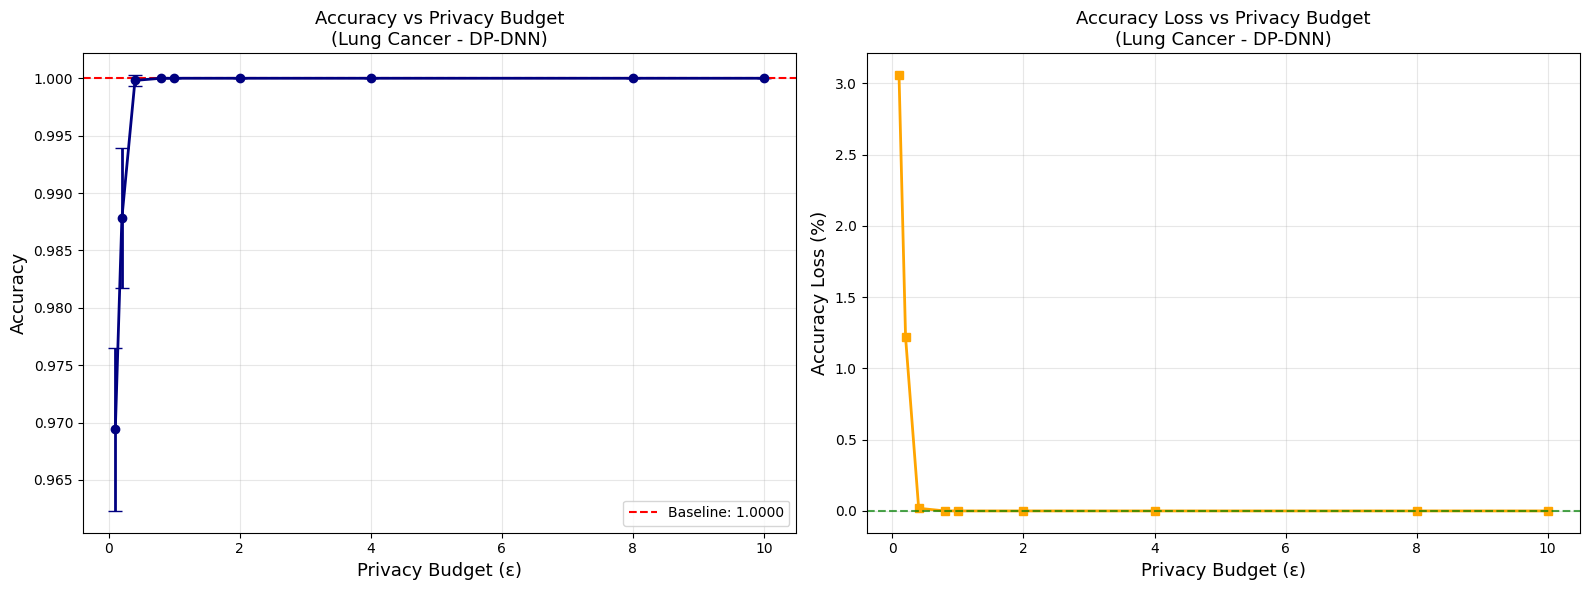

Plot saved to output/dp_dnn_comparison.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].errorbar(results_df['epsilon'], results_df['accuracy_mean'],
                 yerr=results_df['accuracy_std'],
                 marker='o', capsize=5, linewidth=2, color='navy')
if baseline_accuracy is not None:
    axes[0].axhline(y=baseline_accuracy, color='red', linestyle='--',
                    label=f'Baseline: {baseline_accuracy:.4f}')
axes[0].set_xlabel('Privacy Budget (ε)', fontsize=13)
axes[0].set_ylabel('Accuracy', fontsize=13)
axes[0].set_title('Accuracy vs Privacy Budget\n(Lung Cancer - DP-DNN)', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

if 'accuracy_loss_pct' in results_df.columns:
    axes[1].plot(results_df['epsilon'], results_df['accuracy_loss_pct'],
                 marker='s', linewidth=2, color='orange')
    axes[1].axhline(y=0, color='green', linestyle='--', alpha=0.7)
    axes[1].set_xlabel('Privacy Budget (ε)', fontsize=13)
    axes[1].set_ylabel('Accuracy Loss (%)', fontsize=13)
    axes[1].set_title('Accuracy Loss vs Privacy Budget\n(Lung Cancer - DP-DNN)', fontsize=13)
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('output/dp_dnn_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to output/dp_dnn_comparison.png")